In [1]:
!pip install gymnasium stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 12.5 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

# =====================================================================
# 1. 遊戲核心引擎 (FlipGame)
# =====================================================================
class FlipGame:
    def __init__(self):
        # 0=空, 1=正, -1=反, 2=正鬼牌, -2=反鬼牌
        self.board = np.zeros((4, 4), dtype=int)
        self.current_player = 1
        self.scores = {1: [0, 0], 2: [0, 0]} # [條數, 鬼牌數]
        self.game_over = False
        self.winner = None

    def get_valid_moves(self):
        valid_moves = []
        for y in range(4):
            for x in range(4):
                if self.board[y, x] == 0:
                    valid_moves.extend([(y, x, 1), (y, x, -1)])
        return valid_moves

    def step(self, y, x, side, is_joker=False):
        if self.board[y, x] != 0:
            return False, "該位置已有卡牌"

        value = (2 if is_joker else 1) * side
        self.board[y, x] = value

        # 十字翻轉
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        for dy, dx in directions:
            ny, nx = y + dy, x + dx
            if 0 <= ny < 4 and 0 <= nx < 4 and self.board[ny, nx] != 0:
                self.board[ny, nx] *= -1

        self.check_and_collect_lines()
        self.check_winner()

        if not self.game_over:
            self.current_player = 3 - self.current_player
        return True, "成功"

    def check_and_collect_lines(self):
        # 簡單的自動收線邏輯：檢查橫列與直行
        # 檢查橫列
        for y in range(4):
            if np.all(self.board[y, :] > 0) or np.all(self.board[y, :] < 0):
                # 簡單計算這條線裡有沒有鬼牌
                jokers = np.sum(np.abs(self.board[y, :]) == 2)
                self.scores[self.current_player][0] += 1
                self.scores[self.current_player][1] += jokers
                self.board[y, :] = 0 # 收走歸零
                return
        # 檢查直行
        for x in range(4):
            if np.all(self.board[:, x] > 0) or np.all(self.board[:, x] < 0):
                jokers = np.sum(np.abs(self.board[:, x]) == 2)
                self.scores[self.current_player][0] += 1
                self.scores[self.current_player][1] += jokers
                self.board[:, x] = 0
                return

    def check_winner(self):
        for p in [1, 2]:
            lines, jokers = self.scores[p]
            opponent_lines = self.scores[3-p][0]
            if jokers >= 2 or (jokers == 1 and lines >= opponent_lines + 2):
                self.game_over = True
                self.winner = p

# =====================================================================
# 2. Gymnasium 環境轉接層 (FlipGameEnv)
# =====================================================================
class FlipGameEnv(gym.Env):
    def __init__(self):
        super(FlipGameEnv, self).__init__()
        self.game = FlipGame()
        self.action_space = spaces.Discrete(32) 
        self.observation_space = spaces.Box(low=-2, high=2, shape=(4, 4), dtype=np.int8)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.game = FlipGame()
        # 修正 1: 改為 2 張鬼牌，符合對弈規則
        self._place_random_jokers(2) 
        return self.game.board.astype(np.int8), {}

    def step(self, action):
        cell_idx = action // 2
        y, x = cell_idx // 4, cell_idx % 4
        side = 1 if action % 2 == 0 else -1
        
        # 記錄執行前的狀態
        old_joker_count = np.sum(np.abs(self.game.board) == 2)
        
        success, msg = self.game.step(y, x, side, is_joker=False)
        
        if not success:
            return self.game.board.astype(np.int8), -10, True, False, {}
        
        # 修正 2: 獎勵機制更新，鼓勵「沒收鬼牌」
        new_joker_count = np.sum(np.abs(self.game.board) == 2)
        reward = 0
        
        if new_joker_count < old_joker_count:
            reward += 100  # 🌟 成功沒收一張鬼牌，這是最高優先級的獎勵
            
        # 檢查是否還有鬼牌 (根據新規則)
        has_joker = new_joker_count > 0
        if not has_joker:
            # 遊戲結束，根據分數結算
            reward += 200 if self.game.scores[1][0] > self.game.scores[2][0] else -200
            terminated = True
        else:
            terminated = False
            reward -= 0.05 # 微小的步數懲罰，避免 AI 亂下無意義的棋
            
        return self.game.board.astype(np.int8), reward, terminated, False, {}

    def _place_random_jokers(self, count):
        placed = 0
        while placed < count:
            y, x = np.random.randint(0, 4), np.random.randint(0, 4)
            side = np.random.choice([1, -1])
            # 確保不會蓋到已經存在的鬼牌
            if self.game.board[y, x] == 0:
                self.game.step(y, x, side, is_joker=True)
                placed += 1

In [ ]:
# =====================================================================
# 3. 實際啟動訓練的指令 (在 Colab 貼在下一個儲存格執行)
# =====================================================================
import os
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, CallbackList

# 步驟 A: 實例化你寫好的環境
print("正在初始化遊戲環境（已套用鬼牌沒收新規則）...")
env = FlipGameEnv()

# 步驟 B: 讓 Gym 幫你檢查環境格式有沒有邏輯錯誤
check_env(env, warn=True)
print("✅ 環境檢查完成，格式完全符合 Gym 規範！")

# 💡 額外加固：建立 Callback 機制，應對新規則帶來的漫長拉鋸戰
# 每 50,000 步自動儲存一個權重備份，防止 Colab 斷線或後期策略崩壞
checkpoint_callback = CheckpointCallback(
    save_freq=50000, 
    save_path="./logs/checkpoints/",
    name_prefix="ppo_flip_game_v2"
)

print("---")

# 步驟 C: 建立 PPO 模型
# 🎯 因應新規則調整：稍微拉高 learning_rate 並維持 ent_coef，確保 AI 在鬼牌被沒收前的後半場能精算更多步數
print("正在建立 PPO 深度強化學習模型...")
model = PPO(
    "MlpPolicy", 
    env, 
    verbose=1, 
    learning_rate=3e-4,     # 穩定收斂的經典學習率
    ent_coef=0.01,          # 👈 保持探索意願，讓 AI 大膽嘗試翻轉鬼牌或保護鬼牌的下法
    clip_range=0.2,         # 限制策略更新幅度，避免拉鋸戰中獎勵波動過大導致模型暴走
    tensorboard_log="./flip_game_tensorboard/"
)

# 步驟 D: 真正按下「開始訓練」按鈕 (設定跑 100 萬步，因應複雜度提升)
# 修正原本 print 輸出 10 萬步與代碼 100 萬步不符的 Bug
TOTAL_TIMESTEPS = 1000000
print(f"🚀 開始暴力訓練 AI 大腦（目標：{TOTAL_TIMESTEPS:,} 步），請稍候...")

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=checkpoint_callback  # 引入自動存檔機制
)
print(f"🎉 恭喜！{TOTAL_TIMESTEPS:,} 步極限拉鋸戰訓練完成！")

# 步驟 E: 把訓練好的最終模型檔案儲存下來
model.save("ppo_flip_game_model")
print("💾 最終模型已成功儲存為 ppo_flip_game_model.zip！")
print("💡 提示：你可以下載 ./logs/checkpoints/ 中的權重，測試不同訓練階段的 AI 強度。")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/env_checker.py:324: UserWarning: Your observation  has an unconventional shape (neither an image, nor a 1D vector). We recommend you to flatten the observation to have only a 1D vector or use a custom policy to properly process the data.
  warnings.warn(


正在初始化遊戲環境...
環境檢查完成，沒有問題！
正在建立 PPO 深度強化學習模型...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🚀 開始暴力訓練 AI 大腦，請稍候...
Logging to ./flip_game_tensorboard/PPO_1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 3.01     |
|    ep_rew_mean     | -21.8    |
| time/              |          |
|    fps             | 782      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 3.02        |
|    ep_rew_mean          | -19         |
| time/                   |             |
|    fps                  | 675         |
|    iterations           | 2           |
|    time_elapsed         | 6           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004143236 |
|    clip_fraction        | 0.0104      |
|    clip_range           | 0.2         |
|    entropy_loss         | -3.46       |
|    explained_variance   | -0.00184    |
|    learning_rate        | 0.

🚀 開始進行 100 局基準測試 (PPO AI vs 隨機機器人)...

       📊 最終評估報告 (Evaluation Report)       
總測試局數: 100 局
🤖 PPO AI 獲勝: 35 局 | 勝率: 35.0%
🎲 隨機機器人獲勝: 48 局 | 勝率: 48.0%
🤝 平局/未分勝負: 17 局 | 機率: 17.0%
⏱️  平均每局對弈步數: 11.8 步

💡 系統強度診斷：
⚠️ 評等：【需要重訓】勝率過低，AI 可能還在混沌狀態。請檢查是否給予亂下的懲罰不夠大，或是訓練步數太少。


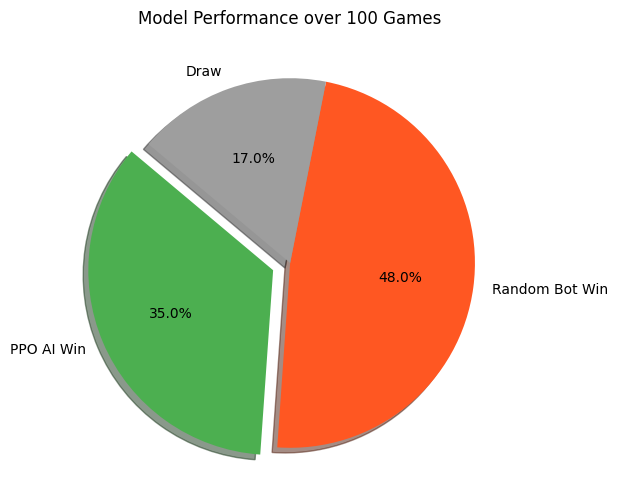

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

def evaluate_vs_random(model_path="ppo_flip_game_model.zip", num_games=100):
    """
    讓訓練好的模型與隨機機器人對戰指定局數，評估其勝率。
    PPO 固定為 玩家 1，隨機機器人固定為 玩家 2。
    """
    try:
        model = PPO.load(model_path)
    except Exception as e:
        print(f"❌ 錯誤：找不到或無法載入模型檔案 {model_path}，請先確認模型已儲存。")
        return

    env = FlipGameEnv()
    ppo_wins = 0
    random_wins = 0
    draws = 0
    game_lengths = []

    print(f"🚀 開始進行 {num_games} 局基準測試 (PPO AI vs 隨機機器人)...")

    for game_idx in range(num_games):
        obs, _ = env.reset()
        done = False
        steps = 0
        
        while not done:
            # 輪到 玩家 1 (PPO AI)
            if env.game.current_player == 1:
                action, _states = model.predict(obs, deterministic=True)
                action = int(action)
                
                # 防呆：如果 AI 預測了不合法的位置，強迫挑選第一個合法步
                cell_idx = action // 2
                y, x = cell_idx // 4, cell_idx % 4
                if env.game.board[y, x] != 0:
                    valid_moves = env.game.get_valid_moves()
                    if valid_moves:
                        v_y, v_x, v_side = valid_moves[0]
                        # 轉回 action 編號
                        action = (v_y * 4 + v_x) * 2 + (0 if v_side == 1 else 1)
                    else:
                        break
                
                obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                
            # 輪到 玩家 2 (隨機機器人)
            else:
                valid_moves = env.game.get_valid_moves()
                if valid_moves:
                    # 隨機挑一步
                    idx = np.random.choice(len(valid_moves))
                    r_y, r_x, r_side = valid_moves[idx]
                    
                    # 執行遊戲引擎內部的 step (不透過 gym 轉接層以免干擾 PPO 的 observation)
                    env.game.step(r_y, r_x, r_side)
                    
                    # 同步更新 env 狀態讓 PPO 下一輪看得到
                    obs = env.game.board.astype(np.int8)
                    done = env.game.game_over
                else:
                    done = True
            
            steps += 1
            if steps > 32: # 安全防禦，避免死結
                break

        # 統計勝負
        game_lengths.append(steps)
        if env.game.winner == 1:
            ppo_wins += 1
        elif env.game.winner == 2:
            random_wins += 1
        else:
            draws += 1

    # =====================================================================
    # 數據計算與圖表輸出
    # =====================================================================
    ppo_win_rate = (ppo_wins / num_games) * 100
    random_win_rate = (random_wins / num_games) * 100
    draw_rate = (draws / num_games) * 100

    print("\n" + "="*40)
    print("       📊 最終評估報告 (Evaluation Report)       ")
    print("="*40)
    print(f"總測試局數: {num_games} 局")
    print(f"🤖 PPO AI 獲勝: {ppo_wins} 局 | 勝率: {ppo_win_rate:.1f}%")
    print(f"🎲 隨機機器人獲勝: {random_wins} 局 | 勝率: {random_win_rate:.1f}%")
    print(f"🤝 平局/未分勝負: {draws} 局 | 機率: {draw_rate:.1f}%")
    print(f"⏱️  平均每局對弈步數: {np.mean(game_lengths):.1f} 步")
    print("="*40)

    # 評估語意化回饋
    print("\n💡 系統強度診斷：")
    if ppo_win_rate >= 85:
        print("🏆 評等：【極強】你的 AI 已經完全掌握了收線基本功，隨機落子根本不是它的對手！")
    elif ppo_win_rate >= 60:
        print("📈 評等：【小有實力】AI 具備一定的連線意識，但可能對策略的選擇還不夠敏銳，建議再增加 20 萬步訓練。")
    else:
        print("⚠️ 評等：【需要重訓】勝率過低，AI 可能還在混沌狀態。請檢查是否給予亂下的懲罰不夠大，或是訓練步數太少。")

    # 繪製圓餅圖
    labels = ['PPO AI Win', 'Random Bot Win', 'Draw']
    sizes = [ppo_wins, random_wins, draws]
    colors = ['#4CAF50', '#FF5722', '#9E9E9E']
    explode = (0.1, 0, 0)  # 凸顯 PPO

    plt.figure(figsize=(6, 6))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
    plt.title(f"Model Performance over {num_games} Games")
    plt.show()

# 執行評估
evaluate_vs_random(num_games=100)